Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading images from: /content/dataset/content/unified_dataset
Successfully loaded 8000 images from 'textiles'
Successfully loaded 8000 images from 'metal'
Successfully loaded 8000 images from 'trash'
Successfully loaded 8000 images from 'organic_waste'
Successfully loaded 8000 images from 'glass'
Successfully loaded 8000 images from 'paper_cardboard'
Successfully loaded 8000 images from 'plastic'
Successfully loaded 8000 images from 'battery'

CRITICAL: Shape of input data matrix is (64000, 12288)
This means the MLP must process 12288 features per image instead of 4,096.

Initializing Scikit-Learn MLPClassifier...
Training MLP on 12,288 RGB features... (This will take a long time and heavily load the CPU)
Iteration 1, loss = 1.96903183
Validation score: 0.332617
Iteration 2, loss = 1.76576515
Validation score: 0.362695
Iteration 3, loss = 1.70142945
Validati

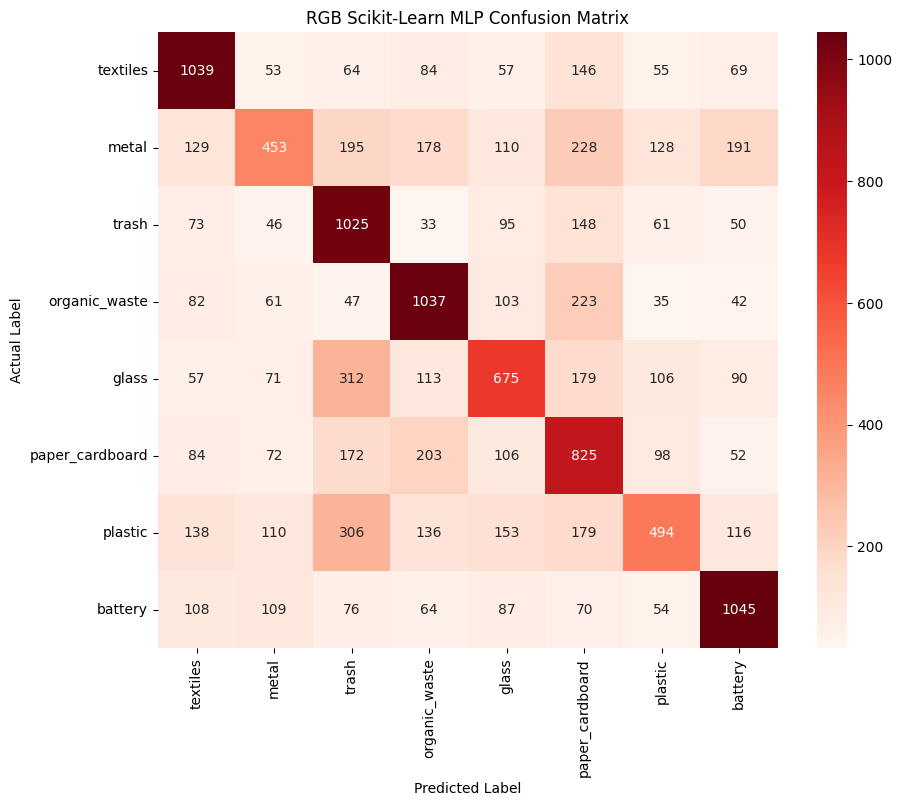

In [4]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 2. Define paths
actual_data_dir = '/content/dataset/content/unified_dataset'
categories = [d for d in os.listdir(actual_data_dir) if os.path.isdir(os.path.join(actual_data_dir, d)) and not d.startswith('._')]

img_size = 64

# 3. Load and preprocess the images in FULL RGB COLOR
data = []
labels = []

print(f"\nLoading images from: {actual_data_dir}")
for category in categories:
    folder_path = os.path.join(actual_data_dir, category)
    class_num = categories.index(category)

    valid_files = [f for f in os.listdir(folder_path) if not f.startswith('._')]
    loaded_count = 0

    for i, img_name in enumerate(valid_files):
        try:
            img_path = os.path.join(folder_path, img_name)
            img_array = cv2.imread(img_path)

            if img_array is not None:
                # Convert from OpenCV's default BGR to standard RGB
                img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img_rgb, (img_size, img_size))

                # FLATTEN the RGB image: 64 x 64 x 3 channels = 12,288 pixels
                flattened_img = resized_img.flatten()

                data.append(flattened_img)
                labels.append(class_num)
                loaded_count += 1

        except Exception as e:
            pass

    print(f"Successfully loaded {loaded_count} images from '{category}'")

# Convert to NumPy arrays and normalize
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(labels)

print(f"\nCRITICAL: Shape of input data matrix is {X.shape}")
print(f"This means the MLP must process {X.shape[1]} features per image instead of 4,096.\n")

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Scikit-Learn MLP on Color Data
print("Initializing Scikit-Learn MLPClassifier...")
print("Training MLP on 12,288 RGB features... (This will take a long time and heavily load the CPU)")
mlp_color = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True, # Critical to stop it before it completely overfits
    random_state=42,
    verbose=True
)

mlp_color.fit(X_train, y_train)

# 6. Evaluate
print("\nTesting the Color MLP model...")
y_pred = mlp_color.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n=======================")
print(f"--- RGB MLP ACCURACY: {accuracy * 100:.2f}% ---")
print(f"=======================\n")

print(classification_report(y_test, y_pred, target_names=categories))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=categories, yticklabels=categories)
plt.title('RGB Scikit-Learn MLP Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [5]:
import joblib

# ==========================================
# 7. SAVE THE RGB MODEL FILE
# ==========================================
# Define the save path inside your existing Aidataset folder
save_dir = '/content/drive/MyDrive/Aidataset/'
model_save_path = os.path.join(save_dir, 'rgb_mlp_model.pkl')

print("\nSaving the RGB Color MLP model file...")
# Export the trained model weights
joblib.dump(mlp_color, model_save_path)

print(f"🎉 RGB MLP Model successfully saved to your Google Drive!")
print(f"File Path: {model_save_path}")


Saving the RGB Color MLP model file...
🎉 RGB MLP Model successfully saved to your Google Drive!
File Path: /content/drive/MyDrive/Aidataset/rgb_mlp_model.pkl
